In [ ]:
import pandas as pd

df = pd.read_csv("../data/Road accident.csv")
df.columns




Index(['Accident_Index', 'Accident Date', 'Day_of_Week', 'Junction_Control',
       'Junction_Detail', 'Accident_Severity', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Carriageway_Hazards', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time',
       'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type'],
      dtype='object')

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (correct relative path)
df = pd.read_csv("../data/Road accident.csv")

# Convert Accident Date to datetime
df['Accident Date'] = pd.to_datetime(df['Accident Date'], errors='coerce')

# Drop rows with invalid dates
df = df.dropna(subset=['Accident Date'])

df.head()


,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,BS0000001,2021-01-01,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,BS0000002,2021-05-01,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,BS0000003,2021-04-01,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,BS0000004,2021-05-01,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,08:10,Urban,Other,Motorcycle over 500cc
4,BS0000005,2021-06-01,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


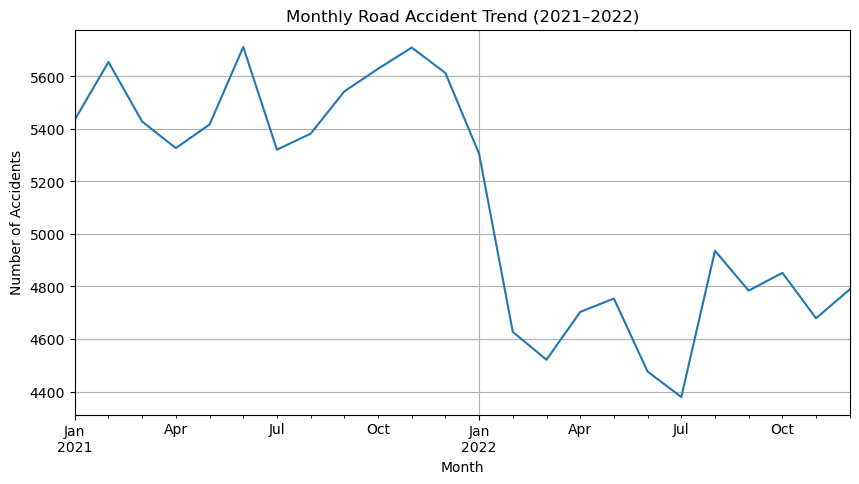

In [7]:
monthly_accidents = (
    df
    .set_index('Accident Date')
    .resample('M')
    .size()
)

plt.figure(figsize=(10,5))
monthly_accidents.plot()
plt.title("Monthly Road Accident Trend (2021–2022)")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.grid(True)
plt.show()


In [8]:
plt.savefig("../visuals/monthly_accident_trend.png")


<Figure size 640x480 with 0 Axes>

Moving Average (Advanced Trend Smoothing)


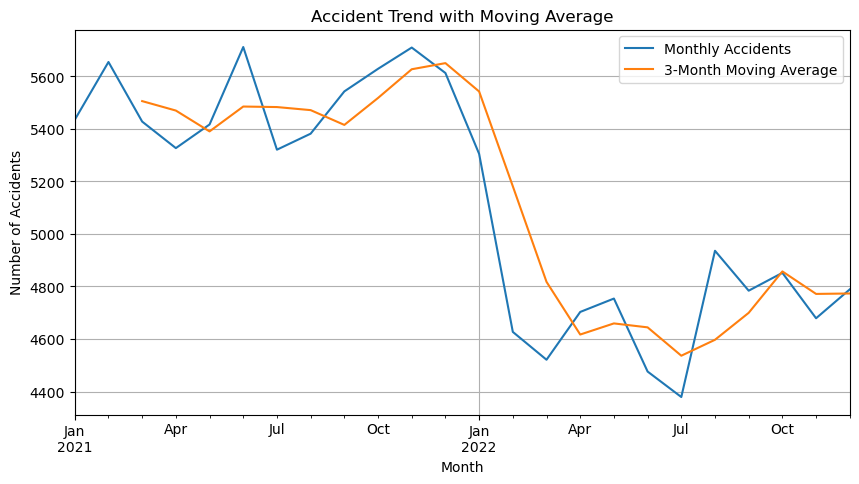

In [9]:
rolling_3 = monthly_accidents.rolling(3).mean()

plt.figure(figsize=(10,5))
monthly_accidents.plot(label="Monthly Accidents")
rolling_3.plot(label="3-Month Moving Average")
plt.legend()
plt.title("Accident Trend with Moving Average")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.grid(True)
plt.show()


In [10]:
plt.savefig("../visuals/moving_average_trend.png")


<Figure size 640x480 with 0 Axes>

Seasonality Analysis (Month-wise Pattern)

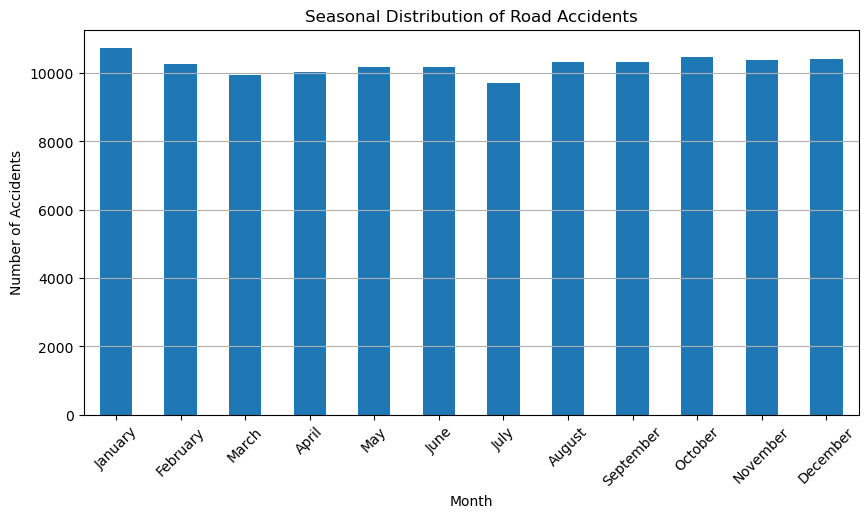

In [11]:
df['Month'] = df['Accident Date'].dt.month_name()

seasonality = df.groupby('Month').size()

seasonality = seasonality.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(10,5))
seasonality.plot(kind='bar')
plt.title("Seasonal Distribution of Road Accidents")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


In [12]:
plt.savefig("../visuals/seasonality_by_month.png")


<Figure size 640x480 with 0 Axes>

Severity Risk Index

In [14]:
severity_weights = {
    'Fatal': 3,
    'Serious': 2,
    'Slight': 1
}

df['Severity_Score'] = df['Accident_Severity'].map(severity_weights)


In [15]:
district_risk = (
    df.groupby('Local_Authority_(District)')['Severity_Score']
    .sum()
    .sort_values(ascending=False)
)

district_risk.head(10)


Local_Authority_(District)
Birmingham          2772.0
Leeds               1916.0
Westminster         1397.0
Manchester          1383.0
Bradford            1352.0
Sheffield           1283.0
Liverpool           1227.0
Cornwall            1168.0
Bristol, City of    1035.0
Cheshire East       1035.0
Name: Severity_Score, dtype: float64

In [16]:
district_risk.head(10).to_csv("../visuals/top_10_high_risk_districts.csv")


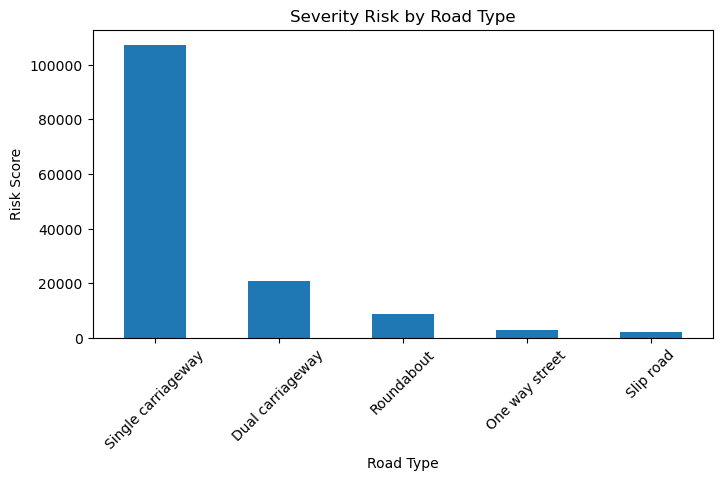

In [17]:
road_risk = (
    df.groupby('Road_Type')['Severity_Score']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,4))
road_risk.plot(kind='bar')
plt.title("Severity Risk by Road Type")
plt.xlabel("Road Type")
plt.ylabel("Risk Score")
plt.xticks(rotation=45)
plt.show()


In [18]:
plt.savefig("../visuals/risk_by_road_type.png")


<Figure size 640x480 with 0 Axes>

## Advanced Analytics Summary

- Time-series analysis revealed a significant decline in accident frequency in early 2022 compared to 2021.
- Moving average smoothing confirmed a sustained downward trend rather than short-term fluctuations.
- Seasonal analysis showed higher accident occurrences toward the end of the year.
- A custom Severity Risk Index identified single carriageway roads as the highest-risk infrastructure.
- District-level risk ranking highlighted priority regions for targeted road safety interventions.


# Level 2 – Diagnostic Analytics (Hypothesis Testing)

This section uses statistical hypothesis testing to determine whether
observed differences in accident severity are statistically significant
or occurred by chance.


🧪 TEST 1 — NIGHT vs DAY SEVERITY
🎯 Business Question

Are accidents at night statistically more severe than during the day?

In [19]:
# Convert Time column to datetime
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce')

# Define Day (6AM–6PM) vs Night
df['Day_Night'] = df['Time'].apply(
    lambda x: 'Night' if (x.hour < 6 or x.hour >= 18) else 'Day'
)


In [20]:
df.groupby('Day_Night')['Severity_Score'].mean()


Day_Night
Day      1.143619
Night    1.189075
Name: Severity_Score, dtype: float64

In [22]:
df[['Severity_Score', 'Day_Night']].isna().sum()


Severity_Score    26
Day_Night          0
dtype: int64

In [23]:
test_df = df.dropna(subset=['Severity_Score'])


In [24]:
day_scores = test_df[test_df['Day_Night'] == 'Day']['Severity_Score']
night_scores = test_df[test_df['Day_Night'] == 'Night']['Severity_Score']


In [25]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    day_scores,
    night_scores,
    alternative='two-sided'
)

stat, p_value


(1485814073.5, 5.473525533406073e-68)

### Hypothesis Test Result: Day vs Night Accident Severity

- Average severity score is higher during night-time accidents compared to day-time.
- A Mann–Whitney U test was applied due to ordinal severity data and non-normal distribution.
- The test result (p-value ≈ 5.47 × 10⁻⁶⁸) indicates a statistically significant difference.
- This confirms that night-time accidents are significantly more severe than day-time accidents.


🧪 TEST 2 — URBAN vs RURAL ACCIDENT SEVERITY

## Hypothesis Test: Urban vs Rural Accident Severity


In [26]:
df['Urban_or_Rural_Area'].value_counts()


Urban_or_Rural_Area
Urban    79306
Rural    43671
Name: count, dtype: int64

🎯 Business Question

Are rural accidents statistically more severe than urban accidents?

In [27]:
df.groupby('Urban_or_Rural_Area')['Severity_Score'].mean()


Urban_or_Rural_Area
Rural    1.199148
Urban    1.133237
Name: Severity_Score, dtype: float64

In [28]:
test_df = df.dropna(subset=['Severity_Score', 'Urban_or_Rural_Area'])


In [29]:
urban_scores = test_df[test_df['Urban_or_Rural_Area'] == 'Urban']['Severity_Score']
rural_scores = test_df[test_df['Urban_or_Rural_Area'] == 'Rural']['Severity_Score']


In [30]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    urban_scores,
    rural_scores,
    alternative='two-sided'
)

stat, p_value


(1638434745.0, 2.6778917228892704e-144)

### Hypothesis Test Result: Urban vs Rural Accident Severity

- Rural accidents have a higher average severity score than urban accidents.
- A Mann–Whitney U test was used due to ordinal severity data and non-normal distribution.
- The test result (p-value ≈ 2.68 × 10⁻¹⁴⁴) indicates a statistically significant difference.
- This confirms that rural accidents tend to result in more severe outcomes compared to urban accidents.
